"""
Jupyter Notebook: GHG Emissions Exploratory Data Analysis
Created: 2026-04-11
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("CES")

CES


In [2]:
df = pd.read_csv(
    '../data/raw/enhanced_ghg_emissions_dataset.csv',
    index_col='Date',
    parse_dates=True
)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nDate Range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst 5 Rows:")
df.head()

Dataset Shape: (168, 6)

Column Names:
['GHG_Emissions_MTCO2e', 'Industrial_Production_Index', 'Temperature_Anomaly_C', 'Energy_Price_Index', 'Year', 'Month']

Date Range: 2011-01-31 00:00:00 to 2024-12-31 00:00:00

First 5 Rows:


,GHG_Emissions_MTCO2e,Industrial_Production_Index,Temperature_Anomaly_C,Energy_Price_Index,Year,Month
Date,,,,,,
2011-01-31,111.42,106.01,-7.44,104.95,2011,1
2011-02-28,107.35,101.30,-8.54,103.53,2011,2
2011-03-31,102.71,101.16,-3.46,107.16,2011,3
2011-04-30,97.64,102.88,0.88,98.45,2011,4
2011-05-31,96.24,101.28,2.99,103.42,2011,5


In [3]:
# DATA QUALITY REPORT
# Missing values
missing = df.isnull().sum()
print(f"\nMissing Values:\n{missing[missing > 0] if missing.sum() > 0 else 'None'}")

# Duplicates
duplicates = df.index.duplicated().sum()
print(f"\nDuplicate Dates: {duplicates}")

# Basic statistics
print(f"\nDescriptive Statistics:")
df.describe().round(2)


Missing Values:
None

Duplicate Dates: 0

Descriptive Statistics:


,GHG_Emissions_MTCO2e,Industrial_Production_Index,Temperature_Anomaly_C,Energy_Price_Index,Year,Month
count,168.00,168.00,168.00,168.00,168.00,168.00
mean,98.59,108.31,1.97,106.81,2017.50,6.50
std,4.80,7.07,6.10,8.06,4.04,3.46
min,86.51,90.22,-9.59,94.73,2011.00,1.00
25%,95.43,103.18,-3.84,102.32,2014.00,3.75
50%,98.30,108.61,1.94,105.15,2017.50,6.50
75%,101.36,113.79,7.49,108.43,2021.00,9.25
max,111.42,123.66,13.29,136.53,2024.00,12.00


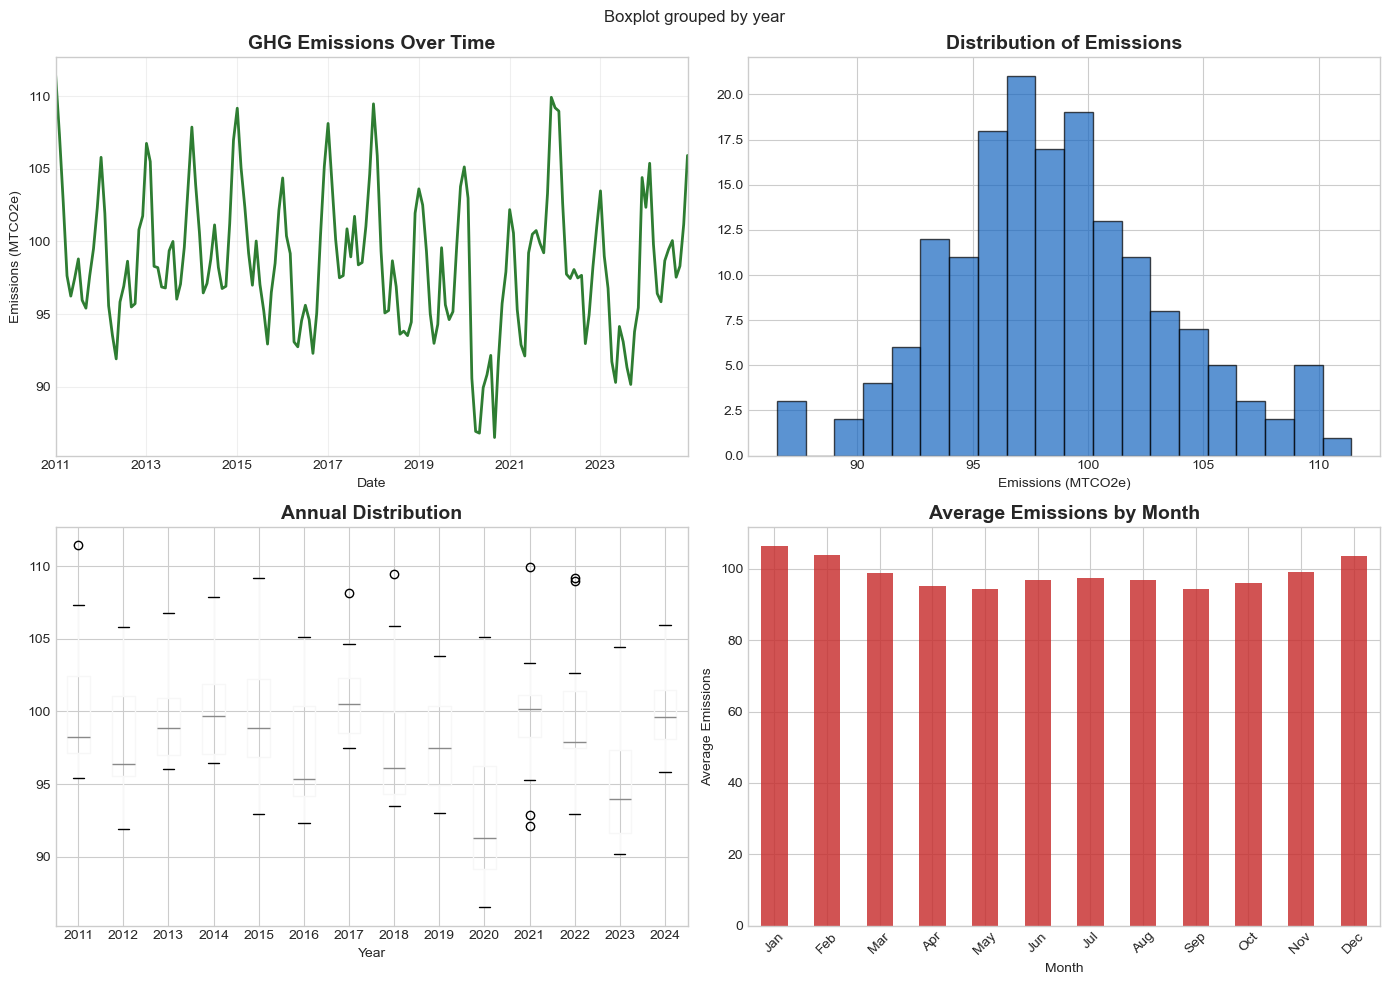


Key Statistics:
Mean: 98.59 MTCO2e
Std: 4.80 MTCO2e
Min: 86.51 MTCO2e
Max: 111.42 MTCO2e


In [5]:
# ## 2. Target Variable Analysis (GHG Emissions)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Time series plot
ax1 = axes[0, 0]
df['GHG_Emissions_MTCO2e'].plot(ax=ax1, color='#2E7D32', linewidth=2)
ax1.set_title('GHG Emissions Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel('Emissions (MTCO2e)')
ax1.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(range(len(df)), df['GHG_Emissions_MTCO2e'], 1)
p = np.poly1d(z)
ax1.plot(df.index, p(range(len(df))), "r--", alpha=0.8, label='Trend')

# Distribution
ax2 = axes[0, 1]
df['GHG_Emissions_MTCO2e'].hist(ax=ax2, bins=20, color='#1565C0', edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Emissions', fontsize=14, fontweight='bold')
ax2.set_xlabel('Emissions (MTCO2e)')

# Box plot by year
ax3 = axes[1, 0]
df['year'] = df.index.year
df.boxplot(column='GHG_Emissions_MTCO2e', by='year', ax=ax3)
ax3.set_title('Annual Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')

# Monthly seasonality
ax4 = axes[1, 1]
monthly_avg = df.groupby(df.index.month)['GHG_Emissions_MTCO2e'].mean()
monthly_avg.plot(kind='bar', ax=ax4, color='#C62828', alpha=0.8)
ax4.set_title('Average Emissions by Month', fontsize=14, fontweight='bold')
ax4.set_xlabel('Month')
ax4.set_ylabel('Average Emissions')
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/eda_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey Statistics:")
print(f"Mean: {df['GHG_Emissions_MTCO2e'].mean():.2f} MTCO2e")
print(f"Std: {df['GHG_Emissions_MTCO2e'].std():.2f} MTCO2e")
print(f"Min: {df['GHG_Emissions_MTCO2e'].min():.2f} MTCO2e")
print(f"Max: {df['GHG_Emissions_MTCO2e'].max():.2f} MTCO2e")

Performing seasonal decomposition...


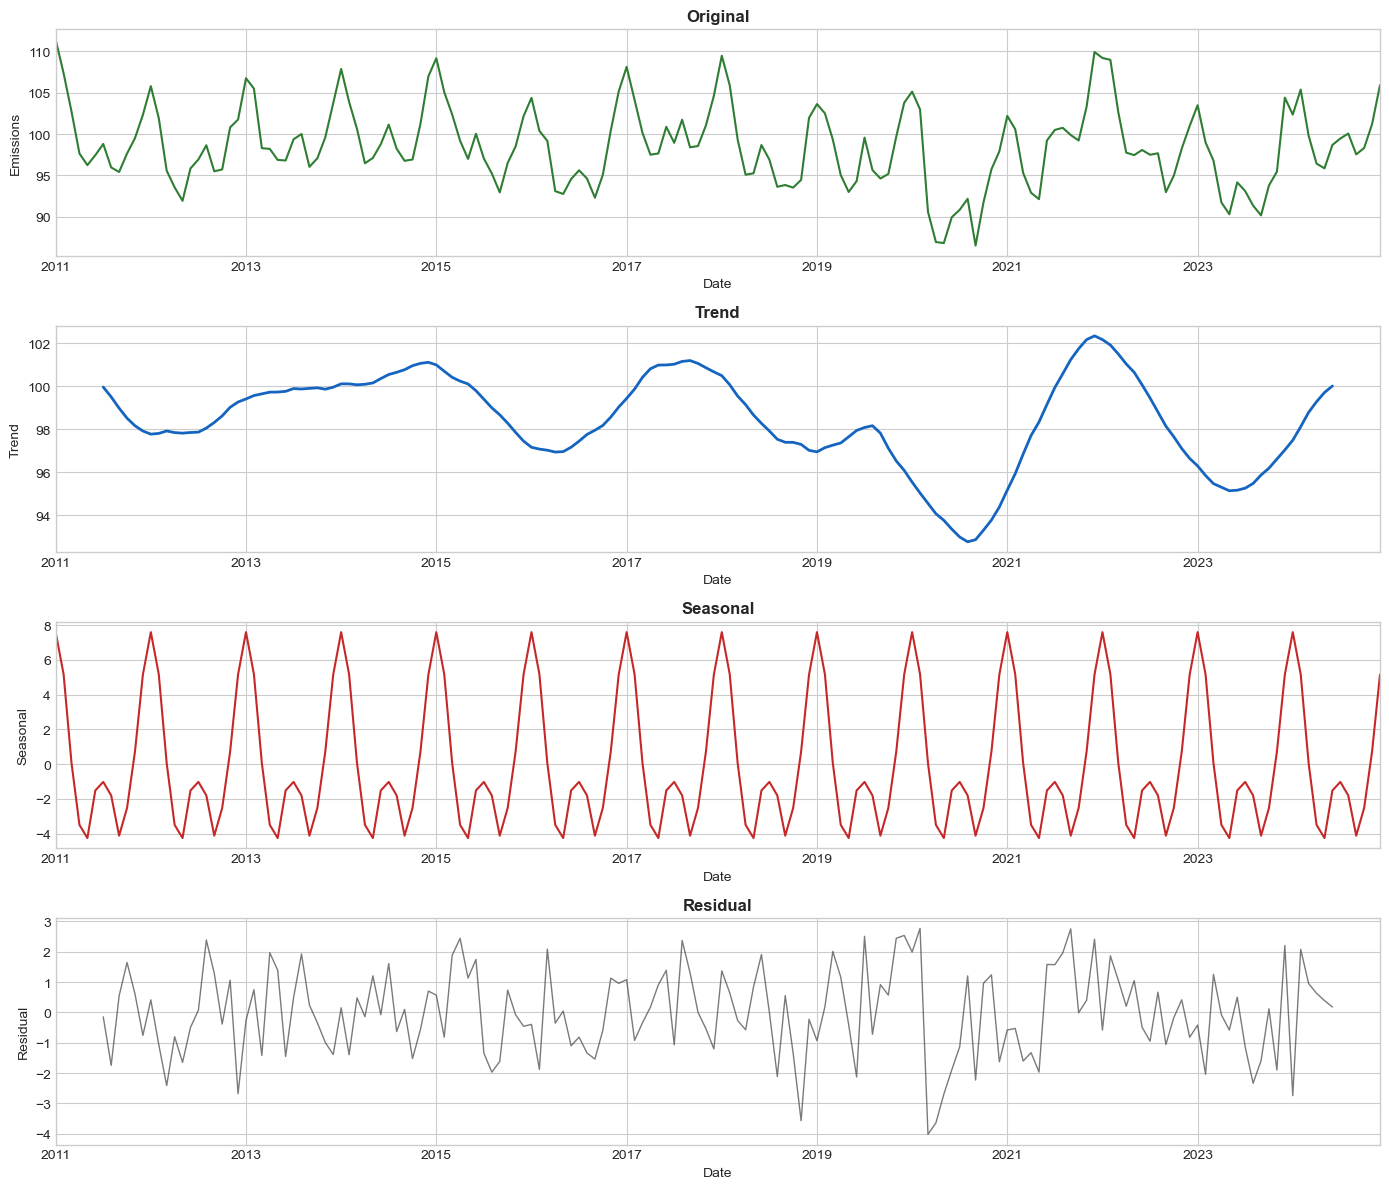

In [6]:
# 3. Time Series Decomposition

print("Performing seasonal decomposition...")

# Decompose the time series
decomposition = seasonal_decompose(
    df['GHG_Emissions_MTCO2e'],
    model='additive',
    period=12
)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=axes[0], color='#2E7D32', linewidth=1.5)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Emissions')

decomposition.trend.plot(ax=axes[1], color='#1565C0', linewidth=2)
axes[1].set_title('Trend', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='#C62828', linewidth=1.5)
axes[2].set_title('Seasonal', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal')

decomposition.resid.plot(ax=axes[3], color='#424242', linewidth=1, alpha=0.7)
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../reports/figures/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

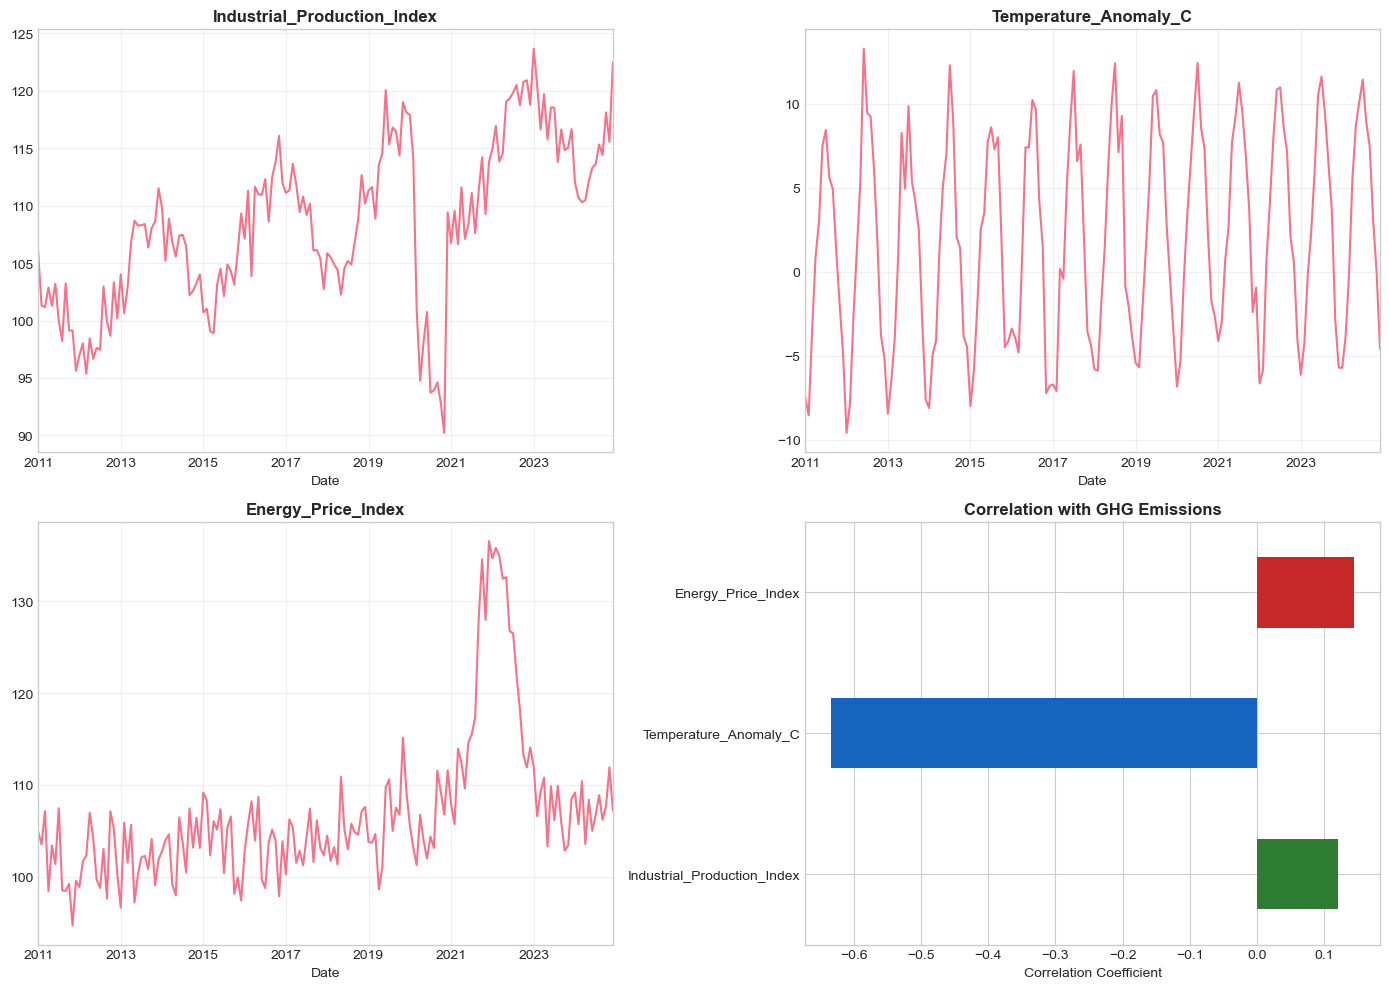


Correlation Matrix:
                             GHG_Emissions_MTCO2e  \
GHG_Emissions_MTCO2e                        1.000   
Industrial_Production_Index                 0.120   
Temperature_Anomaly_C                      -0.633   
Energy_Price_Index                          0.144   

                             Industrial_Production_Index  \
GHG_Emissions_MTCO2e                               0.120   
Industrial_Production_Index                        1.000   
Temperature_Anomaly_C                              0.034   
Energy_Price_Index                                 0.415   

                             Temperature_Anomaly_C  Energy_Price_Index  
GHG_Emissions_MTCO2e                        -0.633               0.144  
Industrial_Production_Index                  0.034               0.415  
Temperature_Anomaly_C                        1.000               0.070  
Energy_Price_Index                           0.070               1.000  


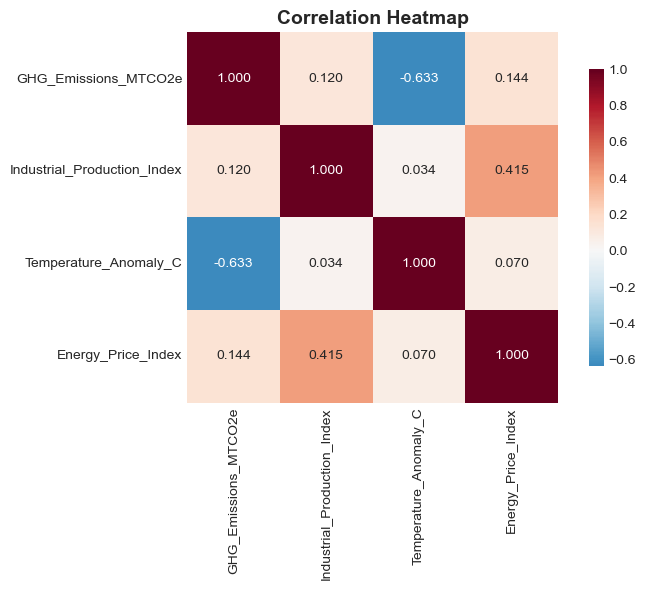

In [7]:
# 4. Exogenous Variables Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

exog_vars = ['Industrial_Production_Index', 'Temperature_Anomaly_C', 'Energy_Price_Index']

# Plot each exogenous variable
for idx, var in enumerate(exog_vars):
    ax = axes[idx // 2, idx % 2]
    df[var].plot(ax=ax, linewidth=1.5)
    ax.set_title(f'{var}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Correlation with target
ax = axes[1, 1]
correlations = df[exog_vars + ['GHG_Emissions_MTCO2e']].corr()['GHG_Emissions_MTCO2e'].drop('GHG_Emissions_MTCO2e')
correlations.plot(kind='barh', ax=ax, color=['#2E7D32', '#1565C0', '#C62828'])
ax.set_title('Correlation with GHG Emissions', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')

plt.tight_layout()
plt.savefig('../reports/figures/eda_exogenous.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation matrix
print("\nCorrelation Matrix:")
corr_matrix = df[['GHG_Emissions_MTCO2e'] + exog_vars].corr()
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 5. Stationarity Testing

def adf_test(series, title=''):
    """Perform Augmented Dickey-Fuller test."""
    result = adfuller(series.dropna())
    print(f'\n{title}')
    print('-' * 40)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("✅ Stationary (reject null hypothesis)")
    else:
        print("❌ Non-stationary (fail to reject null hypothesis)")

# Test original series
adf_test(df['GHG_Emissions_MTCO2e'], 'Original Series')

# Test first difference
adf_test(df['GHG_Emissions_MTCO2e'].diff().dropna(), 'First Difference')

# Test seasonal difference
adf_test(df['GHG_Emissions_MTCO2e'].diff(12).dropna(), 'Seasonal Difference (12)')


Original Series
----------------------------------------
ADF Statistic: -5.7955
p-value: 0.0000
Critical Values:
	1%: -3.4738
	5%: -2.8806
	10%: -2.5769
✅ Stationary (reject null hypothesis)

First Difference
----------------------------------------
ADF Statistic: -3.3460
p-value: 0.0129
Critical Values:
	1%: -3.4741
	5%: -2.8807
	10%: -2.5770
✅ Stationary (reject null hypothesis)

Seasonal Difference (12)
----------------------------------------
ADF Statistic: -4.6789
p-value: 0.0001
Critical Values:
	1%: -3.4769
	5%: -2.8820
	10%: -2.5777
✅ Stationary (reject null hypothesis)


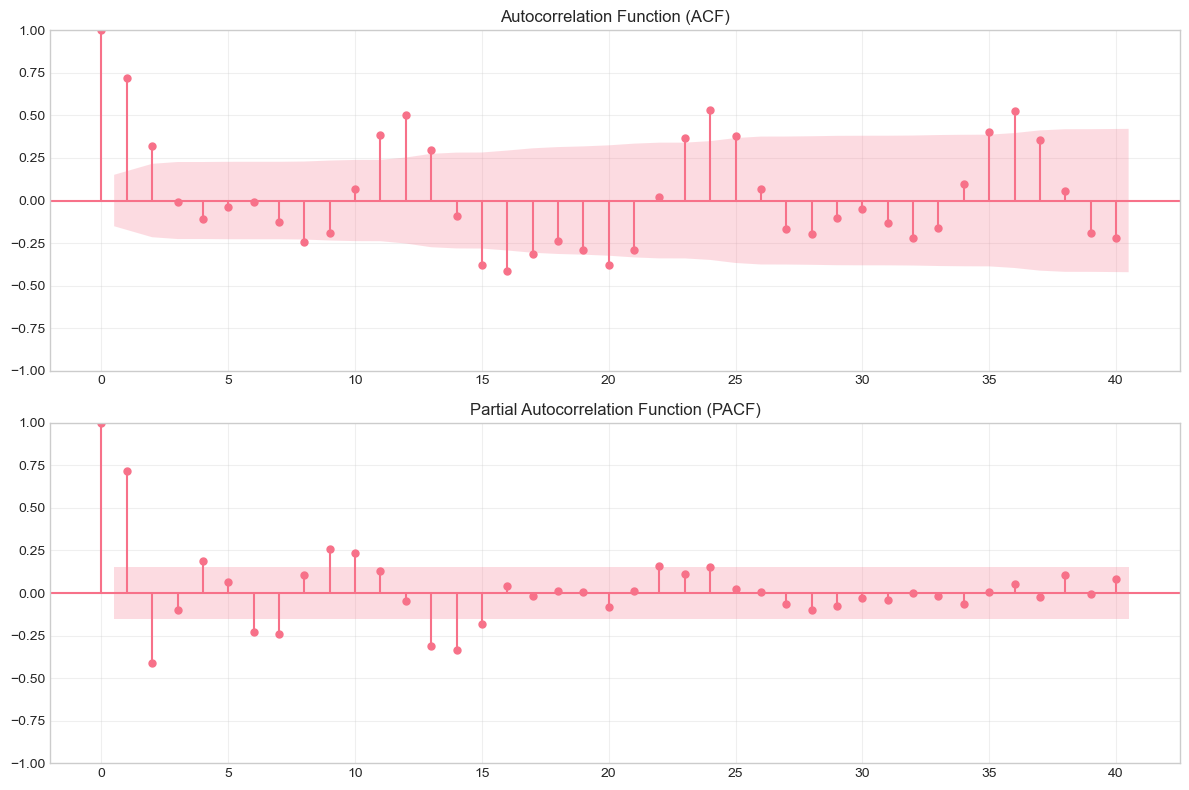

In [9]:
# 6. Autocorrelation Analysis

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ACF
plot_acf(df['GHG_Emissions_MTCO2e'].dropna(), ax=axes[0], lags=40, 
         title='Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(df['GHG_Emissions_MTCO2e'].dropna(), ax=axes[1], lags=40,
          title='Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

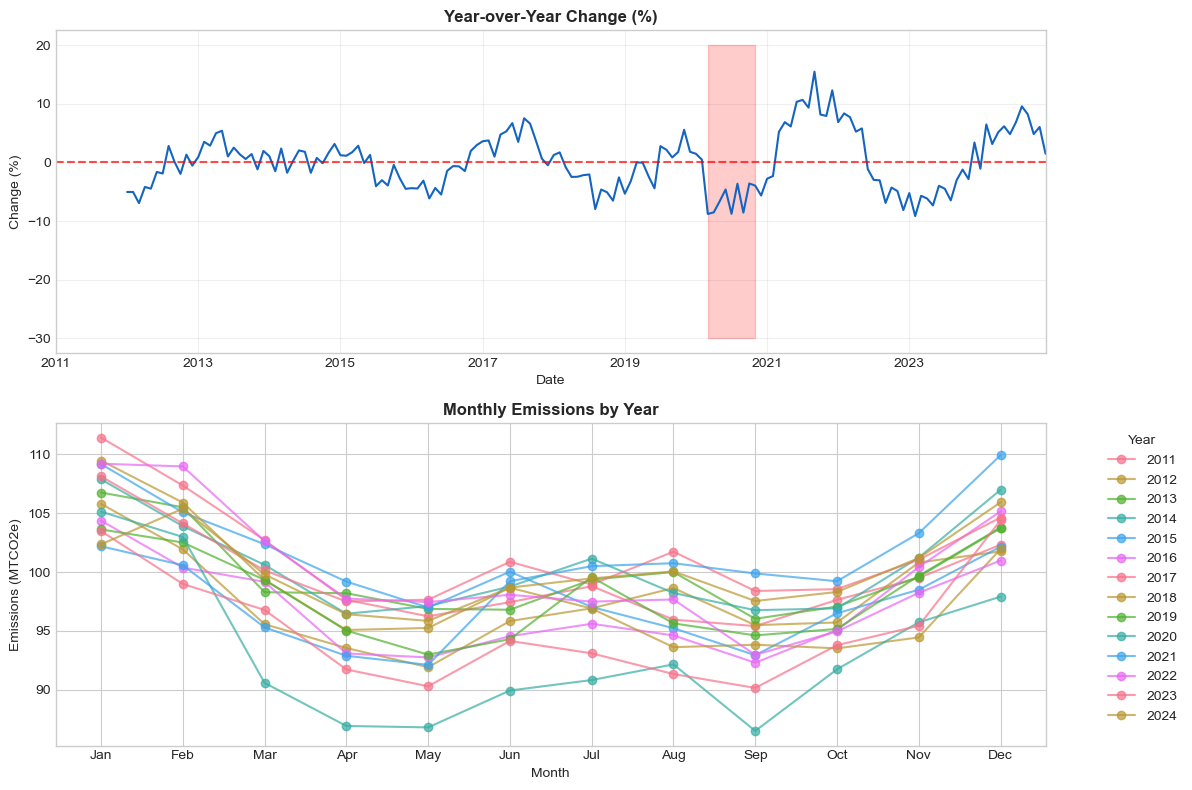


Key Events:
COVID-19 Impact (2020): 93.11 avg
Pre-COVID (2019): 98.02 avg
Recovery (2021): 99.66 avg


In [10]:
# 7. Year-over-Year Analysis

# Calculate year-over-year change
df['yoy_change'] = df['GHG_Emissions_MTCO2e'].pct_change(12) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# YoY change
ax1 = axes[0]
df['yoy_change'].plot(ax=ax1, color='#1565C0', linewidth=1.5)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax1.set_title('Year-over-Year Change (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Change (%)')
ax1.grid(True, alpha=0.3)

# Highlight COVID period
covid_period = (df.index >= '2020-03-01') & (df.index <= '2020-12-01')
ax1.fill_between(df.index, -30, 20, where=covid_period, alpha=0.2, color='red', label='COVID-19 Period')

# Monthly comparison across years
ax2 = axes[1]
pivot_data = df.pivot_table(
    values='GHG_Emissions_MTCO2e',
    index=df.index.month,
    columns=df.index.year,
    aggfunc='mean'
)

pivot_data.plot(ax=ax2, marker='o', alpha=0.7)
ax2.set_title('Monthly Emissions by Year', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Emissions (MTCO2e)')
ax2.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.savefig('../reports/figures/eda_yoy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Events:")
print(f"COVID-19 Impact (2020): {df.loc['2020', 'GHG_Emissions_MTCO2e'].mean():.2f} avg")
print(f"Pre-COVID (2019): {df.loc['2019', 'GHG_Emissions_MTCO2e'].mean():.2f} avg")
print(f"Recovery (2021): {df.loc['2021', 'GHG_Emissions_MTCO2e'].mean():.2f} avg")

In [11]:
# 8. Summary Statistics for Modeling

print("=" * 60)
print("MODELING SUMMARY")
print("=" * 60)

# Train/test split info
train = df[df.index <= '2021-12-31']
test = df[df.index >= '2022-01-01']

print(f"\nRecommended Split:")
print(f"Training: {len(train)} observations ({train.index.min().date()} to {train.index.max().date()})")
print(f"Testing:  {len(test)} observations ({test.index.min().date()} to {test.index.max().date()})")

# Seasonality strength
seasonal_strength = 1 - (decomposition.resid.var() / 
                         (decomposition.seasonal.var() + decomposition.resid.var()))
print(f"\nSeasonality Strength: {seasonal_strength:.2%}")

# Trend strength
trend_strength = 1 - (decomposition.resid.var() / 
                       (decomposition.trend.var() + decomposition.resid.var()))
print(f"Trend Strength: {trend_strength:.2%}")

print("\n" + "=" * 60)
print("EDA COMPLETE - Check reports/figures/ for saved plots")
print("=" * 60)


MODELING SUMMARY

Recommended Split:
Training: 132 observations (2011-01-31 to 2021-12-31)
Testing:  36 observations (2022-01-31 to 2024-12-31)

Seasonality Strength: 87.56%
Trend Strength: 69.03%

EDA COMPLETE - Check reports/figures/ for saved plots
